# Online Payments Fraud Detection
## Projet de Modelisation par Classification
### Objectif
L’objectif de ce projet est de construire un modèle de classification permettant de détecter les transactions frauduleuses dans les paiements en ligne.
### Dataset
Le dataset utilisé provient de la plateforme Kaggle et contient des transactions financières annotées par une variable binaire indiquant si la transaction est frauduleuse ('isFraud=1') ou non('isFraud=0').

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from imblearn.over_sampling import SMOTE
sns.set_style("darkgrid")
sns.set_palette("husl")
plt.ion()  

import warnings
warnings.filterwarnings('ignore')


## Chargement des données
Dans cette section, nous chargeons le dataset des transactions et examinons les premières observations.

In [44]:
data = pd.read_csv("online-payments_fraud.csv")
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [45]:
data_sample = data.sample(200000, random_state=42)

### Échantillon pour les visualisations (EDA)
Cette cellule crée un échantillon aléatoire de 200 000 transactions à partir du dataset complet. Cet échantillon est utilisé uniquement pour les visualisations afin de réduire le temps de calcul et améliorer la lisibilité des graphiques, sans impacter les analyses statistiques ni la phase de modélisation.

In [46]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [47]:
data.describe() 

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


## Analyse de la variable cible (Fraude)
Cette section analyse la distribution des transactions frauduleuses et légitimes afin de mettre en évidence le déséquilibre des classes.


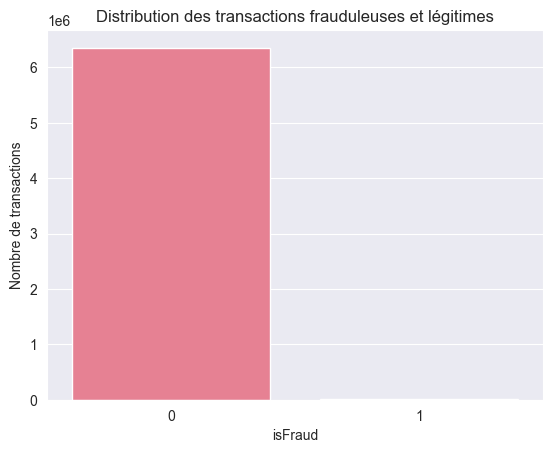

In [48]:
sns.countplot(x='isFraud', data=data)
plt.title("Distribution des transactions frauduleuses et légitimes")
plt.xlabel("isFraud")
plt.ylabel("Nombre de transactions")
plt.show()

## Fraude selon le type de transaction
Cette section analyse la distribution des transactions frauduleuses en fonction du type de transaction.

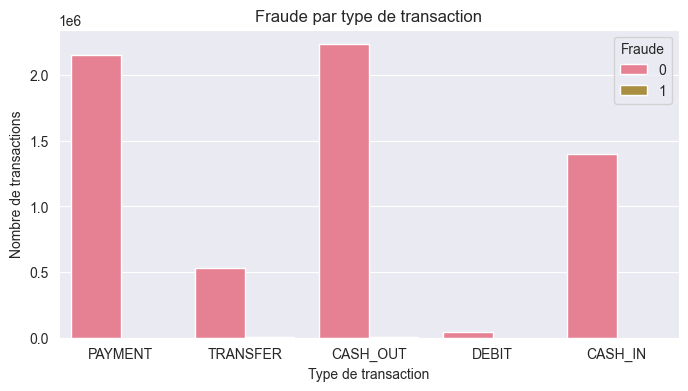

In [49]:
plt.figure(figsize=(8,4))
sns.countplot(x='type', hue='isFraud', data=data)
plt.title("Fraude par type de transaction")
plt.xlabel("Type de transaction")
plt.ylabel("Nombre de transactions")
plt.legend(title="Fraude")
plt.show()


On observe que les transactions frauduleuses sont principalement concentrées sur les types de transaction TRANSFER et CASH_OUT. Les autres types de transactions (PAYMENT, CASH_IN et DEBIT )présentent très peu, voire aucune fraude. Cette observation est cohérente avec les scénarios réels de fraude,où les fraudeurs cherchent à transférer ou retirer rapidement des fonds.

In [50]:
print("="*60)
print("VÉRIFICATIONS SUPPLÉMENTAIRES")
print("="*60)

print("\nValeurs manquantes:")
print(data.isnull().sum())

print(f"\nNombre de doublons: {data.duplicated().sum()}")

print(f"\nDimensions du dataset: {data.shape[0]:,} lignes x {data.shape[1]} colonnes")

VÉRIFICATIONS SUPPLÉMENTAIRES

Valeurs manquantes:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Nombre de doublons: 0

Dimensions du dataset: 6,362,620 lignes x 11 colonnes


Le dataset ne contient pas de valeurs manquantes significatives et ne présente pas de doublons. Les dimensions importantes confirment la nécessité d’un échantillonnage pour certaines visualisations.

In [51]:
fraud_counts = data['isFraud'].value_counts()
fraud_pct = data['isFraud'].value_counts(normalize=True) * 100

print(fraud_counts)
print(fraud_pct)


isFraud
0    6354407
1       8213
Name: count, dtype: int64
isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


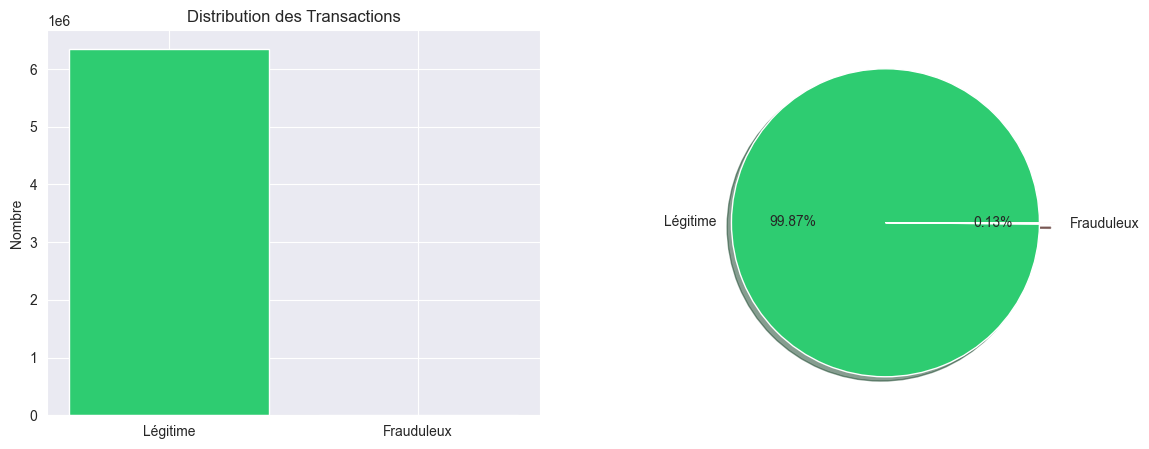

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(['Légitime', 'Frauduleux'], fraud_counts.values,
            color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribution des Transactions')
axes[0].set_ylabel('Nombre')

axes[1].pie(fraud_counts.values,
            labels=['Légitime', 'Frauduleux'],
            autopct='%1.2f%%',
            colors=['#2ecc71', '#e74c3c'],
            explode=(0, 0.1),
            shadow=True)

plt.show()

On observe un fort déséquilibre des classes, avec une proportion de transactions frauduleuses très faible. Ce déséquilibre nécessite l’utilisation de métriques adaptées telles que le recall et le F1-score lors de la modélisation.

In [53]:
fraud_by_type = data[data['isFraud']==1]['type'].value_counts()
fraud_rate = (fraud_by_type / data['type'].value_counts()) * 100

print(fraud_by_type)
print(fraud_rate.sort_values(ascending=False))

type
CASH_OUT    4116
TRANSFER    4097
Name: count, dtype: int64
type
TRANSFER    0.768799
CASH_OUT    0.183955
CASH_IN          NaN
DEBIT            NaN
PAYMENT          NaN
Name: count, dtype: float64


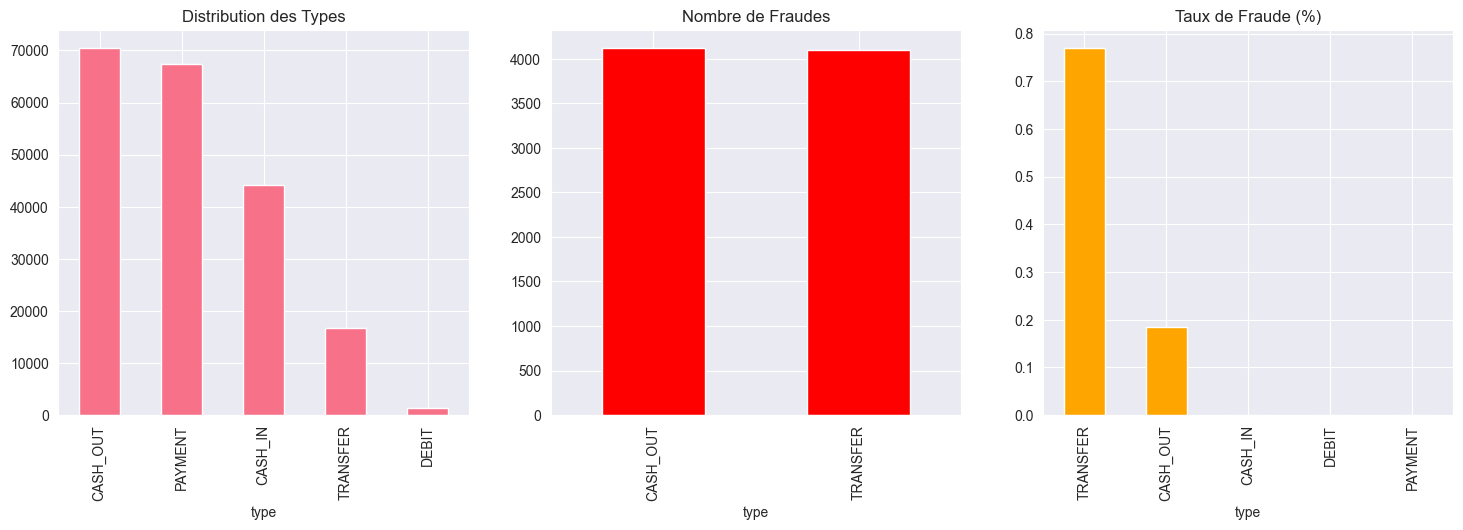

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

data_sample['type'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Distribution des Types')

fraud_by_type.plot(kind='bar', ax=axes[1], color='red')
axes[1].set_title('Nombre de Fraudes')

fraud_rate.sort_values(ascending=False).plot(kind='bar', ax=axes[2], color='orange')
axes[2].set_title('Taux de Fraude (%)')

plt.show()

Les transactions frauduleuses sont principalement concentrées sur les types TRANSFER et CASH_OUT, ce qui correspond aux scénarios réels de fraude visant à transférer ou retirer rapidement des fonds.

In [55]:
print(data['amount'].describe())
print(data[data['isFraud']==1]['amount'].describe())

count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64
count    8.213000e+03
mean     1.467967e+06
std      2.404253e+06
min      0.000000e+00
25%      1.270913e+05
50%      4.414234e+05
75%      1.517771e+06
max      1.000000e+07
Name: amount, dtype: float64


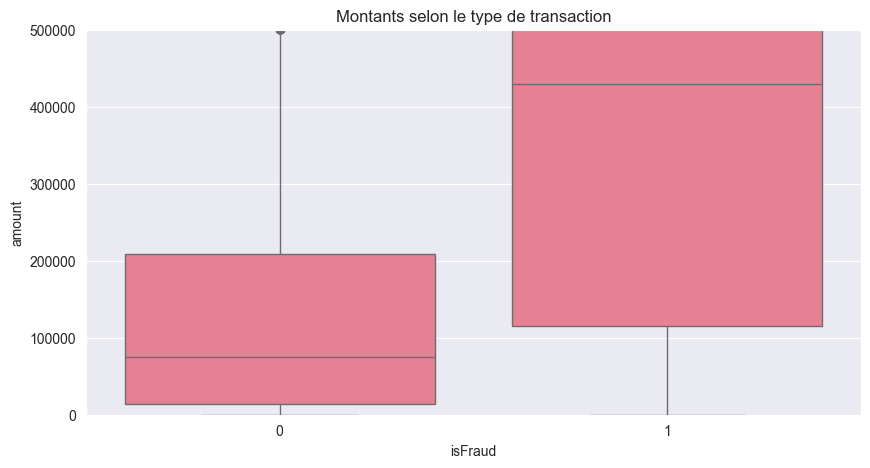

In [56]:
plt.figure(figsize=(10,5))
sns.boxplot(x='isFraud', y='amount', data=data_sample)
plt.ylim(0, 500000)
plt.title('Montants selon le type de transaction')
plt.show()

Les transactions frauduleuses présentent des montants atypiques et une dispersion plus élevée, ce qui en fait une variable discriminante pour la détection de fraude.

In [57]:
data['balanceOrig_diff'] = data['newbalanceOrig'] - data['oldbalanceOrg']
data['balanceDest_diff'] = data['newbalanceDest'] - data['oldbalanceDest']

data['amount_check_orig'] = np.abs(data['balanceOrig_diff'] + data['amount']) < 0.01
data['amount_check_dest'] = np.abs(data['balanceDest_diff'] - data['amount']) < 0.01

suspicious = data[~data['amount_check_orig'] | ~data['amount_check_dest']]
print(f"Taux de fraude parmi les suspectes: {suspicious['isFraud'].mean()*100:.2f}%")

Taux de fraude parmi les suspectes: 0.08%


Les incohérences entre les soldes et les montants sont fortement corrélées à la fraude, suggérant que ces variables peuvent être exploitées pour améliorer la détection.

In [58]:
numeric_cols = data.select_dtypes(include=[np.number]).columns
corr = data[numeric_cols].corr()

print(corr['isFraud'].sort_values(ascending=False))

isFraud             1.000000
amount              0.076688
isFlaggedFraud      0.044109
step                0.031578
balanceDest_diff    0.027028
oldbalanceOrg       0.010154
newbalanceDest      0.000535
oldbalanceDest     -0.005885
newbalanceOrig     -0.008148
balanceOrig_diff   -0.362472
Name: isFraud, dtype: float64


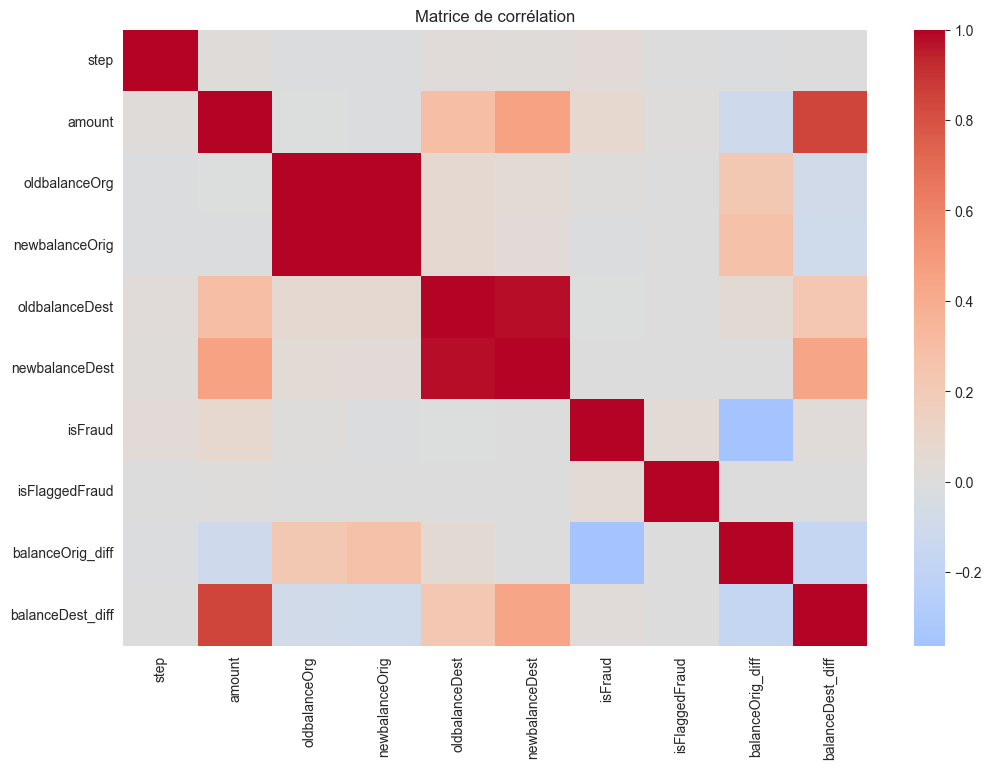

In [59]:
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Matrice de corrélation')
plt.show()

L’analyse exploratoire a permis d’identifier les variables clés, le déséquilibre des classes et les comportements typiques des transactions frauduleuses. Ces observations guident le choix des techniques de prétraitement et de modélisation.

## Préparation des données
Cette étape consiste à supprimer les variables non pertinentes
avant la phase de modélisation.

In [60]:
data_ml = data.drop(['nameOrig', 'nameDest'], axis=1)

Les variables créées uniquement pour l’analyse exploratoire ne sont pas conservées pour l’apprentissage du modèle.

In [61]:
data_ml = data_ml.drop([
    'balanceOrig_diff',
    'balanceDest_diff',
    'amount_check_orig',
    'amount_check_dest'
], axis=1)

## Encodage et séparation des données

Les variables catégorielles sont encodées et les données sont séparées en variables explicatives et cible.

In [62]:
le = LabelEncoder()
data_ml['type'] = le.fit_transform(data_ml['type'])

La variable cible est séparée des variables explicatives.

In [63]:
X = data_ml.drop('isFraud', axis=1)
y = data_ml['isFraud']

Les données sont divisées en ensembles d’entraînement et de test en conservant la proportion des classes.

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Normalisation des données
Les variables numériques sont normalisées afin d’améliorer la convergence des modèles.

In [65]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## Modèle 1 — Régression Logistique
La régression logistique est utilisée comme modèle de base (baseline) en raison de sa simplicité et de son interprétabilité.Elle permet d’obtenir un premier point de comparaison.

In [66]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

### Évaluation du modèle
Les performances sont évaluées à l’aide de métriques adaptées
aux données déséquilibrées.

In [67]:
from sklearn.metrics import classification_report

print("🔹 Régression Logistique")
print(classification_report(y_test, y_pred_log))

🔹 Régression Logistique
              precision    recall  f1-score   support

           0       1.00      0.97      0.98   1270881
           1       0.04      0.90      0.07      1643

    accuracy                           0.97   1272524
   macro avg       0.52      0.93      0.53   1272524
weighted avg       1.00      0.97      0.98   1272524



La régression logistique fournit une baseline interprétable.Cependant, le recall reste limité, ce qui est insuffisant dans un contexte de détection de fraude où les faux négatifs sont critiques.

## Modèle 2 — Random Forest
Le Random Forest est un modèle d’ensemble capable de capturer des relations non linéaires entre les variables.Il est particulièrement adapté aux problèmes complexes
comme la détection de fraude.

In [68]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

Les résultats du Random Forest sont comparés à ceux de la régression logistique.

In [69]:
from sklearn.metrics import classification_report

print("Random Forest")
print(classification_report(y_test, y_pred_rf))


Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.98      0.78      0.87      1643

    accuracy                           1.00   1272524
   macro avg       0.99      0.89      0.94   1272524
weighted avg       1.00      1.00      1.00   1272524



Le modèle Random Forest surpasse la régression logistique,notamment en termes de recall et de F1-score.Ces améliorations sont cruciales pour réduire le nombre de fraudes non détectées.

## Matrice de confusion
La matrice de confusion permet d’analyser les erreurs de classification du modèle.Elle montre le nombre de vrais positifs, faux positifs, vrais négatifs et faux négatifs.

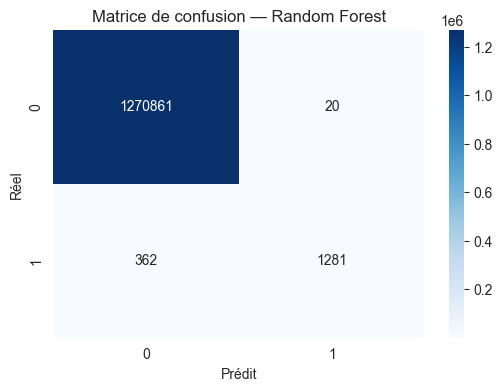

In [70]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion — Random Forest")
plt.show()


La matrice de confusion montre que le modèle Random Forest identifie bien les transactions frauduleuses (haut recall),tout en réduisant les faux positifs.Cependant, l’optimisation des faux négatifs reste cruciale.

## Courbe ROC et AUC
La courbe ROC permet d’évaluer la capacité du modèle à distinguer
les transactions frauduleuses des transactions légitimes.
L’aire sous la courbe (AUC) résume cette performance.

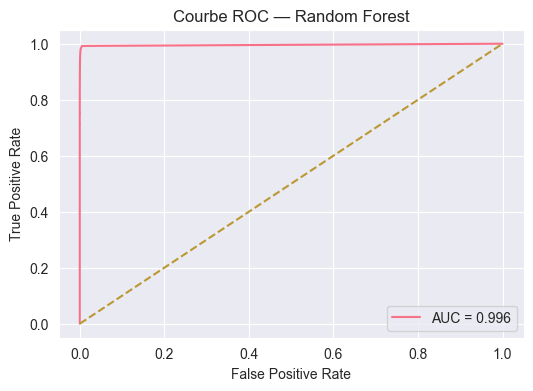

In [71]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probabilités prédites pour la classe "fraude"
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Calcul ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_rf)
auc = roc_auc_score(y_test, y_proba_rf)

# Tracé de la courbe
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC — Random Forest")
plt.legend()
plt.show()


La courbe ROC montre une bonne capacité de discrimination du modèle.La valeur élevée de l’AUC confirme que le Random Forest est performant pour distinguer les transactions frauduleuses des transactions légitimes.


## Conclusion
Les résultats montrent que le modèle Random Forest surpasse la régression logistique, notamment en termes de recall et de F1-score.Ces performances sont essentielles dans un contexte de détection de fraude, où les fraudes non détectées sont coûteuses.


## Conclusion générale
Ce projet a permis de construire un système de détection de fraude
basé sur des modèles de classification. L’analyse exploratoire a mis
en évidence un fort déséquilibre des classes et des comportements
caractéristiques des transactions frauduleuses. Les résultats montrent
que le modèle Random Forest offre les meilleures performances, notamment
en termes de recall et de F1-score, ce qui est crucial pour limiter les
fraudes non détectées.
